In [5]:
library(Seurat)
library(Signac)
library(ggplot2)
library(dplyr)
library(cowplot)
library(tibble)
library(scales)
library(viridisLite)
library(grid)


In [6]:
# Set up multithreading for faster processing

library(future)
plan("multicore", workers = 16)


In [7]:
# Set working directory; change this to your local directory if you are running the code locally

setwd('/gpfs/commons/groups/vickovic_lab/rhe/projects/005/space_tag_reproducibility/fig1')


#### Figure 1f: Spatial Splotch posterior scores for marker genes

This notebook loads the registered SPACE-Tag Seurat objects, attaches the locally saved Splotch posterior values for `Satb2`, `Tcf7l2`, and `Zeb2`, and recreates the three-by-three marker gene panel shown in Figure 1f.


In [8]:
splotch_dir <- 'processed_data/space-tag/splotch_betas'
genes_use <- c('Satb2', 'Tcf7l2', 'Zeb2')

assay_objects <- list(
  h3k27ac = readRDS('processed_data/space-tag/p28_brain_h3k27ac_merged_registered.rds'),
  h3k4me3 = readRDS('processed_data/space-tag/p28_brain_h3k4me3_merged_registered.rds'),
  h3k27me3 = readRDS('processed_data/space-tag/p28_brain_h3k27me3_merged_registered.rds')
)

assay_tables <- list(
  h3k27ac = read.delim(file.path(splotch_dir, 'h3k27ac_marker_gene_posterior_lambdas.tsv')),
  h3k4me3 = read.delim(file.path(splotch_dir, 'h3k4me3_marker_gene_posterior_lambdas.tsv')),
  h3k27me3 = read.delim(file.path(splotch_dir, 'h3k27me3_marker_gene_posterior_lambdas.tsv'))
)

plot_limits <- list(
  h3k27ac = list(Satb2 = c(1.2, 2.4), Tcf7l2 = c(0.8, 2.4), Zeb2 = c(2.0, 6.0)),
  h3k4me3 = list(Satb2 = c(0.8, 1.6), Tcf7l2 = c(0.6, 1.8), Zeb2 = c(1.2, 2.4)),
  h3k27me3 = list(Satb2 = c(1.0, 2.2), Tcf7l2 = c(1.0, 1.8), Zeb2 = c(0.6, 2.2))
)

score_labels <- c(
  h3k27ac = 'Activity score',
  h3k4me3 = 'Activity score',
  h3k27me3 = 'Repression score'
)

row_labels <- c(
  h3k27ac = 'H3K27ac',
  h3k4me3 = 'H3K4me3',
  h3k27me3 = 'H3K27me3'
)


In [14]:
make_coord_key <- function(sample, registered_col, registered_row, digits = 5) {
  paste(
    sample,
    sprintf(paste0('%.', digits, 'f'), round(registered_col, digits)),
    sprintf(paste0('%.', digits, 'f'), round(registered_row, digits)),
    sep = '|'
  )
}

attach_splotch_scores <- function(seurat_obj, score_table, gene_columns, digits = 5) {
  coords_df <- seurat_obj@images[['image']]@coordinates %>%
    as.data.frame() %>%
    rownames_to_column('cell_id') %>%
    mutate(
      sample = sub('_(.*)$', '', cell_id),
      coord_key = make_coord_key(sample, registered_col, registered_row, digits)
    )

  score_lookup <- score_table %>%
    mutate(coord_key = make_coord_key(sample, registered_col, registered_row, digits))

  if (anyDuplicated(score_lookup$coord_key) > 0) {
    stop('Coordinate keys are not unique in the Splotch lookup table.')
  }

  match_index <- match(coords_df$coord_key, score_lookup$coord_key)

  for (gene in gene_columns) {
    seurat_obj@meta.data[[gene]] <- score_lookup[[gene]][match_index]
  }

  message(sprintf('Matched %s / %s cells', sum(!is.na(match_index)), length(match_index)))
  seurat_obj
}

build_plot_df <- function(seurat_obj, feature_name) {
  coords_df <- seurat_obj@images[['image']]@coordinates %>%
    as.data.frame() %>%
    rownames_to_column('cell_id')
  coords_df$feature_value <- seurat_obj@meta.data[coords_df$cell_id, feature_name]
  coords_df
}

plot_splotch_panel <- function(seurat_obj, feature_name, limits, score_label, plot_title = NULL) {
  plot_df <- build_plot_df(seurat_obj, feature_name) %>%
    filter(!is.na(feature_value))

  ggplot(plot_df, aes(x = 1.6 * registered_col, y = registered_row, color = feature_value)) +
    geom_point(size = 1, stroke = 0) +
    scale_color_gradientn(
      colors = viridisLite::magma(100),
      limits = limits,
      oob = scales::squish,
      breaks = pretty(limits, n = 4),
      name = score_label
    ) +
    coord_equal() +
    ggtitle(plot_title) +
    guides(
      color = guide_colorbar(
        barheight = unit(35, 'mm'),
        barwidth = unit(3, 'mm'),
        ticks.colour = 'black',
        frame.colour = 'black'
      )
    ) +
    theme_void() +
    theme(
      plot.title = element_text(hjust = 0.5, face = 'bold', size = 15),
      legend.title = element_text(size = 12),
      legend.text = element_text(size = 10),
      legend.position = 'right',
      plot.margin = margin(5, 5, 5, 5)
    )
}

make_row_label <- function(label_text) {
  ggdraw() + draw_label(label_text, fontface = 'bold', size = 16, x = 0.98, hjust = 1)
}


In [15]:
for (assay_name in names(assay_objects)) {
  cat(assay_name, '\n')
  assay_objects[[assay_name]] <- attach_splotch_scores(
    assay_objects[[assay_name]],
    assay_tables[[assay_name]],
    genes_use
  )
}


h3k27ac 


Matched 15386 / 15386 cells



h3k4me3 


Matched 24122 / 24132 cells



h3k27me3 


Matched 23911 / 23919 cells



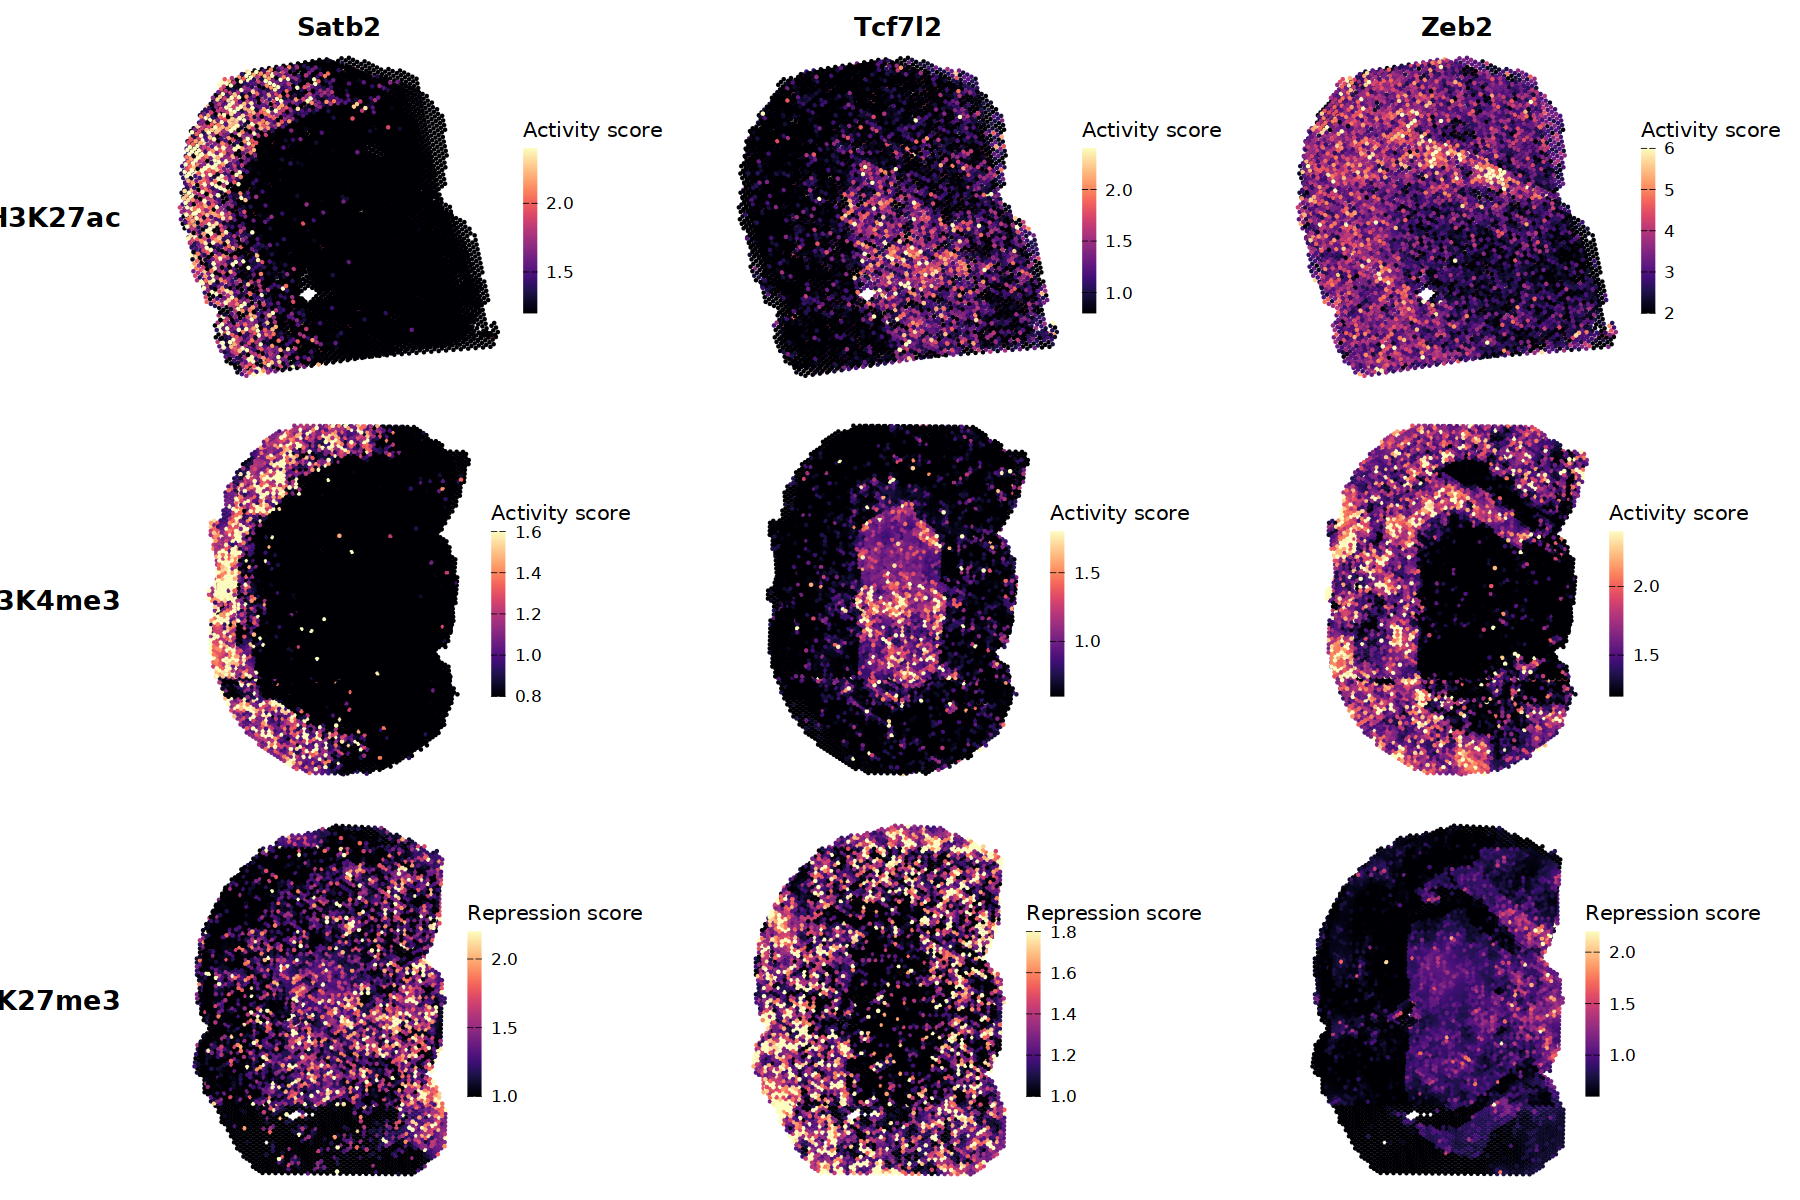

In [16]:
options(repr.plot.width = 15, repr.plot.height = 10)

row_1 <- plot_grid(
  make_row_label(row_labels[['h3k27ac']]),
  plot_splotch_panel(assay_objects[['h3k27ac']], 'Satb2', plot_limits[['h3k27ac']][['Satb2']], score_labels[['h3k27ac']], 'Satb2'),
  plot_splotch_panel(assay_objects[['h3k27ac']], 'Tcf7l2', plot_limits[['h3k27ac']][['Tcf7l2']], score_labels[['h3k27ac']], 'Tcf7l2'),
  plot_splotch_panel(assay_objects[['h3k27ac']], 'Zeb2', plot_limits[['h3k27ac']][['Zeb2']], score_labels[['h3k27ac']], 'Zeb2'),
  nrow = 1,
  rel_widths = c(0.22, 1, 1, 1),
  align = 'h'
)

row_2 <- plot_grid(
  make_row_label(row_labels[['h3k4me3']]),
  plot_splotch_panel(assay_objects[['h3k4me3']], 'Satb2', plot_limits[['h3k4me3']][['Satb2']], score_labels[['h3k4me3']]),
  plot_splotch_panel(assay_objects[['h3k4me3']], 'Tcf7l2', plot_limits[['h3k4me3']][['Tcf7l2']], score_labels[['h3k4me3']]),
  plot_splotch_panel(assay_objects[['h3k4me3']], 'Zeb2', plot_limits[['h3k4me3']][['Zeb2']], score_labels[['h3k4me3']]),
  nrow = 1,
  rel_widths = c(0.22, 1, 1, 1),
  align = 'h'
)

row_3 <- plot_grid(
  make_row_label(row_labels[['h3k27me3']]),
  plot_splotch_panel(assay_objects[['h3k27me3']], 'Satb2', plot_limits[['h3k27me3']][['Satb2']], score_labels[['h3k27me3']]),
  plot_splotch_panel(assay_objects[['h3k27me3']], 'Tcf7l2', plot_limits[['h3k27me3']][['Tcf7l2']], score_labels[['h3k27me3']]),
  plot_splotch_panel(assay_objects[['h3k27me3']], 'Zeb2', plot_limits[['h3k27me3']][['Zeb2']], score_labels[['h3k27me3']]),
  nrow = 1,
  rel_widths = c(0.22, 1, 1, 1),
  align = 'h'
)

figure_1f <- plot_grid(
  row_1,
  row_2,
  row_3,
  ncol = 1,
  rel_heights = c(1, 1, 1)
)

figure_1f
